# Mini-Project on Netflix User Watching Behavior Using Dataset from Kaggle

## Structure of my Mini-Project

1. Importing and Reading CSV File
2. Manipulation with Data Frame, Creation of Insights
3. Conclusion 

## Getting started with importing all necessary libraries

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Download latest version
path = kagglehub.dataset_download("rhythmghai/netflix-user-watching-behavior-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\aquag\.cache\kagglehub\datasets\rhythmghai\netflix-user-watching-behavior-dataset\versions\1


# Reading the CSV file using Pandas and Pathlib

In [3]:

dataset_dir = Path(path)
csv_files = sorted(dataset_dir.rglob("*.csv"))

if not csv_files:
	raise FileNotFoundError(f"No CSV files found in: {dataset_dir}")

df = pd.read_csv(csv_files[0], index_col='user_id')

print(f"Loaded file: {csv_files[0]}")

Loaded file: C:\Users\aquag\.cache\kagglehub\datasets\rhythmghai\netflix-user-watching-behavior-dataset\versions\1\netflix_user_behavior_dataset.csv


# Displaying first 5 elements of a dataset

In [3]:
print(df.head())

         age  gender country  account_age_months subscription_type  \
user_id                                                              
U100000   56    Male   India                  17          Standard   
U100001   46  Female     USA                  20          Standard   
U100002   32   Other     USA                  25             Basic   
U100003   60    Male  Canada                  37          Standard   
U100004   25    Male  Brazil                  23           Premium   

         monthly_fee payment_method primary_device  devices_used  \
user_id                                                            
U100000        15.99         PayPal         Laptop             1   
U100001        12.99         PayPal         Tablet             2   
U100002        15.99         PayPal         Tablet             2   
U100003        12.99         PayPal       Smart TV             3   
U100004        12.99         PayPal         Mobile             3   

        favorite_genre  avg_watc

# Let's see the most popular subscription 

<Axes: title={'center': 'Bar chart of subscriptions'}, xlabel='subscription_type', ylabel='People with subscription'>

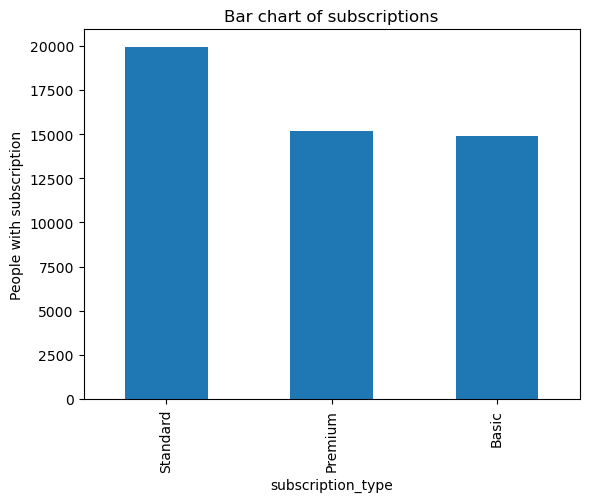

In [68]:
df['subscription_type'].value_counts().plot(
    kind='bar', 
    title='Bar chart of subscriptions',
    ylabel='People with subscription')


> Insight: Users buy the Standard subscription more than any other. It shows that people are mostly interested in the 'middle' option. It is a counterweight between expensive Premium and Basic subscription with limited quality of streaming. 
### *Now let's try to find out subscriptions by country!* 

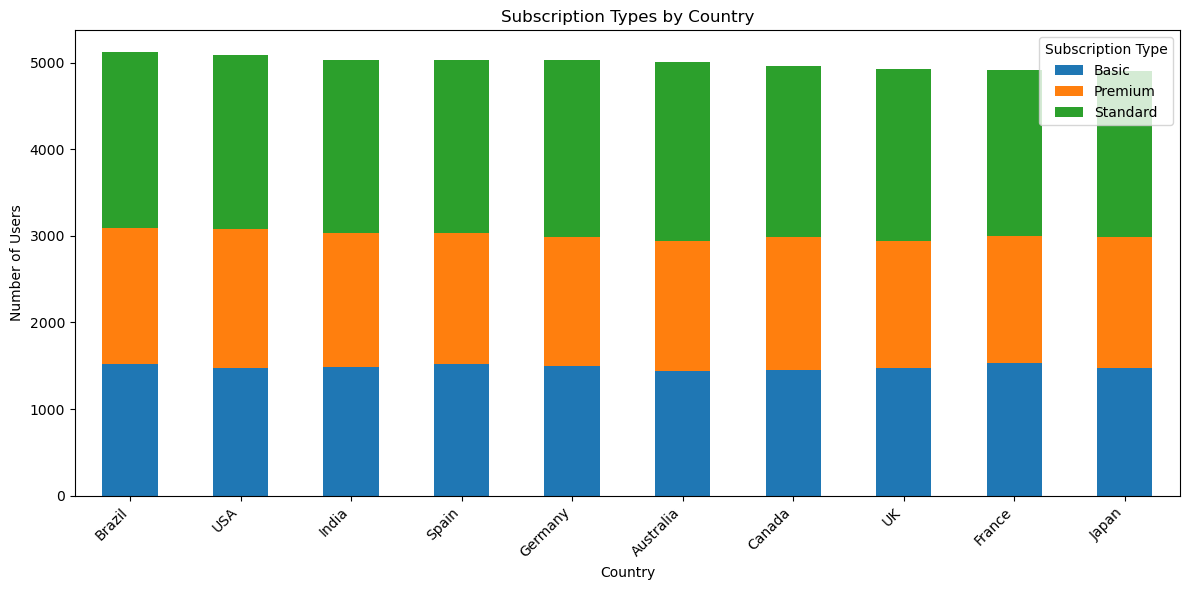

In [ ]:
grouped = df.groupby(['country', 'subscription_type']).size().unstack(fill_value=0)

grouped = grouped.loc[grouped.sum(axis=1).sort_values(ascending=False).index]

grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6))

plt.title('Subscription Types by Country')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription Type')
plt.tight_layout()
plt.show()

> Insight 2: Brazil leads by user count, yet Standard subscriptions dominate there as much as elsewhere 

*Now I am going to check number of users by different genres*

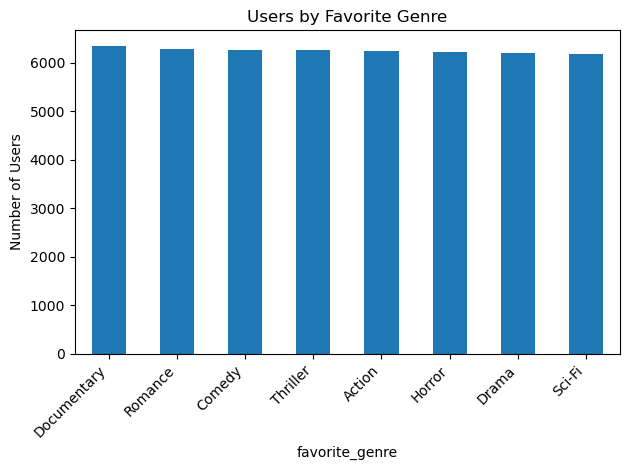

In [ ]:
df_reset = df.reset_index()
grouped = df_reset.groupby('favorite_genre')['user_id'].count().sort_values(ascending=False)

grouped.plot(
    kind='bar',
    title='Users by Favorite Genre',
    ylabel='Number of Users')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> Insight 3: the most popular genre is Documentary! The reason is unclear from this dataset alone.

## Let's see the average age group of Netflix users using pie chart

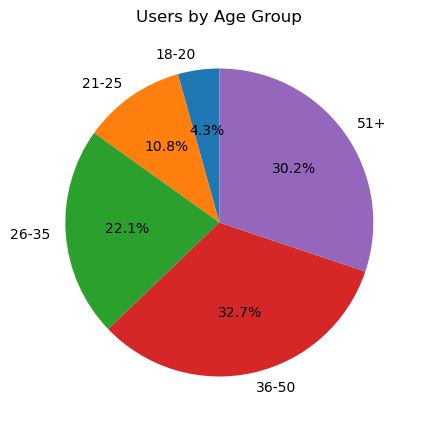

In [34]:
bins = [18, 20, 25, 35, 50, 100]
labels = ['18-20','21-25', '26-35', '36-50', '51+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

counts = df['age_group'].value_counts().reindex(labels)

plt.figure(figsize=(5, 5))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Users by Age Group')
plt.show()

> Insight 4: Users Between 36-50 y.o use Netflix the most.

## Who uses Netflix the most? Men or women? Let's find out 

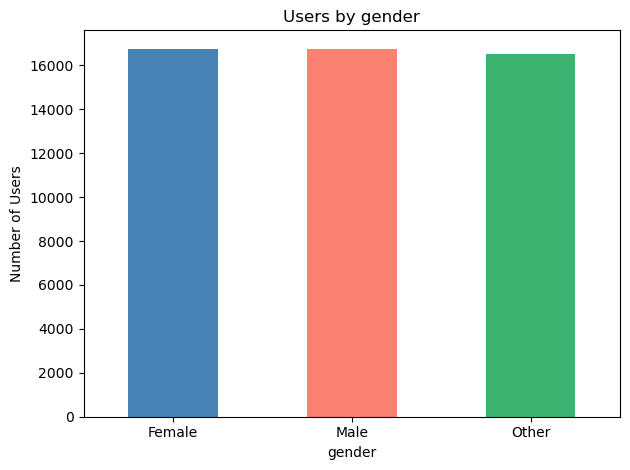

In [60]:
df['gender'].value_counts().sort_values(ascending=False).plot(
    kind='bar', 
    title='Users by gender',
    ylabel='Number of Users',
    color=['steelblue', 'salmon', 'mediumseagreen'])

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> Insight 5: There is almost no difference in gender, it means the dataset is well-balanced

# Conclusion

## What I Learned:

1. Creating different types of charts using Matplotlib
2. Making useful insights from real-world data
3. Working with big datasets from Kaggle

## Taking next steps:

1. Learning how to use PowerBI
2. Trying more complex EDA of a dataset
3. Learning basics of economics for finance analysis
4. EDA of a 'dirty' dataset